In [3]:
# ============================================================
# Neural Network From Scratch — Complete Single-Cell Version
# XOR training + visualization
#
# External requirements:
#   - NumPy
#   - Matplotlib
#
# This cell contains:
#   1. Base Layer class
#   2. Dense layer
#   3. Generic Activation layer
#   4. Tanh activation
#   5. Sigmoid activation
#   6. Mean Squared Error loss
#   7. Forward prediction
#   8. Backpropagation training loop
#   9. XOR dataset
#  10. Network construction
#  11. Training
#  12. Predictions
#  13. Loss visualization
#  14. 3D decision-surface visualization
# ============================================================

In [4]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

In [5]:
# ============================================================
# Base Layer
# ============================================================


class Layer:
    """
    Base class for every neural-network layer.

    Each layer must implement:

    forward(input):
        Receives the input of the layer and returns its output.

    backward(output_gradient, learning_rate):
        Receives the gradient of the loss with respect to the layer's output,
        calculates the gradient with respect to the layer's input, and updates
        trainable parameters when the layer contains any.
    """

    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        raise NotImplementedError(
            "Every layer must implement its own forward() method."
        )

    def backward(self, output_gradient, learning_rate):
        raise NotImplementedError(
            "Every layer must implement its own backward() method."
        )


# ============================================================
# Dense / Fully Connected Layer
# ============================================================


class Dense(Layer):
    """
    A fully connected neural-network layer.

    If the input has shape:

        (input_size, 1)

    and the layer contains output_size neurons, then:

        weights shape = (output_size, input_size)
        bias shape    = (output_size, 1)
        output shape  = (output_size, 1)

    Forward propagation:

        Y = W @ X + B

    Backpropagation:

        dE/dW = dE/dY @ X.T
        dE/dB = dE/dY
        dE/dX = W.T @ dE/dY
    """

    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_size = input_size
        self.output_size = output_size

        # Randomly initialize the trainable parameters.
        #
        # weights:
        # Each row contains the weights of one neuron.
        #
        # bias:
        # Each output neuron receives one bias value.
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        """
        Calculate the output of the layer.

        Y = W @ X + B
        """

        self.input = input
        self.output = np.dot(self.weights, self.input) + self.bias
        return self.output

    def backward(self, output_gradient, learning_rate):
        """
        Perform backpropagation through the Dense layer.

        output_gradient represents:

            dE/dY

        where:
            E = loss/error
            Y = output of this layer
        """

        # Gradient of the loss with respect to the weights:
        #
        # dE/dW = dE/dY @ X.T
        weights_gradient = np.dot(output_gradient, self.input.T)

        # Gradient of the loss with respect to the input:
        #
        # dE/dX = W.T @ dE/dY
        #
        # This must be calculated before updating the weights so that
        # the gradient uses the same weights that were used during the
        # corresponding forward pass.
        input_gradient = np.dot(self.weights.T, output_gradient)

        # Gradient-descent parameter update:
        #
        # new_parameter =
        #     old_parameter - learning_rate * parameter_gradient
        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        # Return the input gradient so that the previous layer can continue
        # the backpropagation process.
        return input_gradient


# ============================================================
# Generic Activation Layer
# ============================================================


class Activation(Layer):
    """
    Generic activation layer.

    An Activation object receives:

        function:
            The activation function f(x).

        function_derivative:
            The derivative f'(x).

    Forward propagation:

        Y = f(X)

    Backpropagation:

        dE/dX = dE/dY ⊙ f'(X)

    where ⊙ is element-wise multiplication.
    """

    def __init__(self, function, function_derivative):
        super().__init__()
        self.function = function
        self.function_derivative = function_derivative

    def forward(self, input):
        """Apply the activation function element by element."""

        self.input = input
        self.output = self.function(self.input)
        return self.output

    def backward(self, output_gradient, learning_rate):
        """
        Apply the chain rule:

            dE/dX = dE/dY ⊙ f'(X)

        Activation layers do not contain trainable parameters, so the
        learning_rate argument is accepted for API consistency but is
        not used.
        """

        input_gradient = np.multiply(
            output_gradient,
            self.function_derivative(self.input),
        )

        return input_gradient

In [6]:
# ============================================================
# Tanh Activation
# ============================================================


class Tanh(Activation):
    """
    Hyperbolic-tangent activation.

    Function:

        tanh(x)

    Derivative:

        1 - tanh(x)^2

    Output range:

        (-1, 1)
    """

    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_derivative(x):
            return 1 - np.tanh(x) ** 2

        super().__init__(
            function=tanh,
            function_derivative=tanh_derivative,
        )


# ============================================================
# Sigmoid Activation
# ============================================================


class Sigmoid(Activation):
    """
    Sigmoid activation.

    Function:

        sigmoid(x) = 1 / (1 + exp(-x))

    Derivative:

        sigmoid(x) * (1 - sigmoid(x))

    Output range:

        (0, 1)
    """

    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_derivative(x):
            sigmoid_output = sigmoid(x)
            return sigmoid_output * (1 - sigmoid_output)

        super().__init__(
            function=sigmoid,
            function_derivative=sigmoid_derivative,
        )


# ============================================================
# Loss Function — Mean Squared Error
# ============================================================


def mse(y_true, y_pred):
    """
    Mean Squared Error.

    Formula:

        MSE = mean((y_true - y_pred)^2)
    """

    return np.mean(np.power(y_true - y_pred, 2))


def mse_derivative(y_true, y_pred):
    """
    Derivative of Mean Squared Error with respect to y_pred.

    If:

        E = mean((y_true - y_pred)^2)

    then:

        dE/dy_pred = 2 * (y_pred - y_true) / number_of_values
    """

    return 2 * (y_pred - y_true) / np.size(y_true)


# Alias matching the name used by the separated implementation.
mse_prime = mse_derivative

In [15]:
# ============================================================
# Prediction / Forward Propagation
# ============================================================


def predict(network, input):
    """
    Pass an input through every layer in the network.

    The output of one layer becomes the input of the next layer.
    """

    output = input

    for layer in network:
        output = layer.forward(output)

    return output


# ============================================================
# Training
# ============================================================


def train(
    network,
    loss,
    loss_derivative,
    X_train,
    Y_train,
    epochs=10_000,
    learning_rate=0.01,
    verbose=True,
    print_every=10,
):
    """
    Train the neural network using sample-by-sample gradient descent.

    For every epoch:

        1. Send every training sample through the network.
        2. Calculate its loss.
        3. Calculate the derivative of the loss.
        4. Send the gradient backward through all layers.
        5. Update the trainable parameters.
        6. Calculate the average epoch loss.

    Returns:
        A NumPy array containing the average loss from every epoch.
    """

    loss_history = []

    for epoch in range(epochs):
        epoch_error = 0.0

        for x, y in zip(X_train, Y_train):

            # ------------------------------------------------
            # Forward propagation
            # ------------------------------------------------

            output = predict(network, x)

            # ------------------------------------------------
            # Calculate loss
            # ------------------------------------------------

            epoch_error += loss(y, output)

            # ------------------------------------------------
            # Initial loss gradient
            # ------------------------------------------------

            gradient = loss_derivative(y, output)

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------
            #
            # Gradients must flow in the reverse order:
            #
            # output layer -> ... -> input layer
            # ------------------------------------------------

            for layer in reversed(network):
                gradient = layer.backward(gradient, learning_rate)

        # Average error across the training samples.
        epoch_error /= len(X_train)
        loss_history.append(epoch_error)

        if (
            verbose
            and print_every is not None
            and epoch % print_every == 0
        ):
            print(
                f"Epoch {epoch + 1:4d}/{epochs}, "
                f"loss={epoch_error:.10f}"
            )

    return np.array(loss_history)

In [16]:
# ============================================================
# XOR Dataset
# ============================================================

# XOR truth table:
#
#  x1  x2  |  y
# ----------------
#   0   0   |  0
#   0   1   |  1
#   1   0   |  1
#   1   1   |  0
#
# Every input is represented as a two-dimensional column vector:
#
#     [[x1],
#      [x2]]
#
# Therefore, X has shape:
#
#     (4 samples, 2 features, 1 column)
#
# Y has shape:
#
#     (4 samples, 1 output, 1 column)


X = np.reshape(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ],
    (4, 2, 1),
)

Y = np.reshape(
    [
        [0],
        [1],
        [1],
        [0],
    ],
    (4, 1, 1),
)

In [26]:
# ============================================================
# Network Architecture
# ============================================================

# Architecture:
#
# Input:
#     2 values: x1 and x2
#
# Hidden layer:
#     Dense(2, 3)
#     Tanh
#
# Output layer:
#     Dense(3, 1)
#     Tanh
#
# Flow:
#
#     [x1, x2]
#         ↓
#     Dense: 2 → 3
#         ↓
#       Tanh
#         ↓
#     Dense: 3 → 1
#         ↓
#       Tanh
#         ↓
#     prediction


network = [
    Dense(input_size=2, output_size=3),
    Tanh(),
    Dense(input_size=3, output_size=1),
    Tanh(),
]


# ============================================================
# Train the XOR Network
# ============================================================


loss_history = train(
    network=network,
    loss=mse,
    loss_derivative=mse_derivative,
    X_train=X,
    Y_train=Y,
    epochs=1000,
    learning_rate=0.1,
    verbose=True,
    print_every=10,
)


# ============================================================
# Display XOR Predictions
# ============================================================


print("\n" + "=" * 68)
print("XOR PREDICTIONS")
print("=" * 68)

prediction_rows = []

for x, expected in zip(X, Y):
    prediction = predict(network, x)

    x1 = int(x[0, 0])
    x2 = int(x[1, 0])
    expected_value = float(expected[0, 0])
    predicted_value = float(prediction[0, 0])

    # Tanh outputs may be slightly below zero or above one.
    # For the XOR classification decision, 0.5 is used as the threshold.
    predicted_class = int(predicted_value >= 0.5)

    prediction_rows.append(
        {
            "x1": x1,
            "x2": x2,
            "expected": int(expected_value),
            "raw_prediction": predicted_value,
            "predicted_class": predicted_class,
        }
    )

    print(
        f"Input: ({x1}, {x2}) | "
        f"Expected: {int(expected_value)} | "
        f"Raw prediction: {predicted_value:.6f} | "
        f"Predicted class: {predicted_class}"
    )

Epoch    1/1000, loss=0.5156899621
Epoch   11/1000, loss=0.3388989883
Epoch   21/1000, loss=0.3306255932
Epoch   31/1000, loss=0.3275865748
Epoch   41/1000, loss=0.3249661269
Epoch   51/1000, loss=0.3214387372
Epoch   61/1000, loss=0.3161252171
Epoch   71/1000, loss=0.3077463570
Epoch   81/1000, loss=0.2939698113
Epoch   91/1000, loss=0.2715006803
Epoch  101/1000, loss=0.2399160099
Epoch  111/1000, loss=0.2104498575
Epoch  121/1000, loss=0.1899084975
Epoch  131/1000, loss=0.1649223508
Epoch  141/1000, loss=0.1181415228
Epoch  151/1000, loss=0.0608290783
Epoch  161/1000, loss=0.0301770056
Epoch  171/1000, loss=0.0180311218
Epoch  181/1000, loss=0.0123678136
Epoch  191/1000, loss=0.0092423396
Epoch  201/1000, loss=0.0073034378
Epoch  211/1000, loss=0.0059987699
Epoch  221/1000, loss=0.0050677426
Epoch  231/1000, loss=0.0043733819
Epoch  241/1000, loss=0.0038375064
Epoch  251/1000, loss=0.0034125247
Epoch  261/1000, loss=0.0030679357
Epoch  271/1000, loss=0.0027833523
Epoch  281/1000, los

In [27]:
# ============================================================
# Calculate XOR Classification Accuracy
# ============================================================


correct_predictions = sum(
    row["predicted_class"] == row["expected"]
    for row in prediction_rows
)

accuracy = correct_predictions / len(prediction_rows)

print("-" * 68)
print(f"Accuracy: {correct_predictions}/{len(prediction_rows)}")
print(f"Accuracy percentage: {accuracy * 100:.2f}%")
print(f"Final training loss: {loss_history[-1]:.10f}")
print("=" * 68)

--------------------------------------------------------------------
Accuracy: 4/4
Accuracy percentage: 100.00%
Final training loss: 0.0003143288


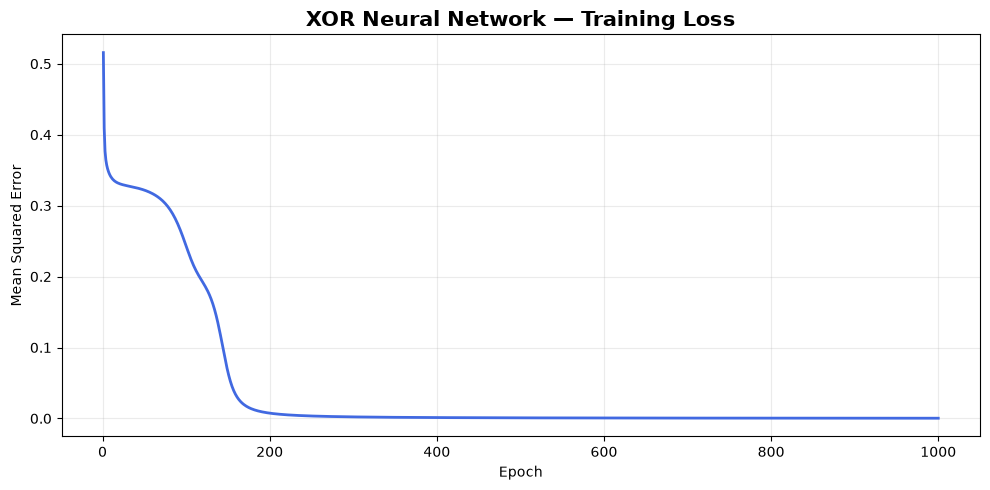

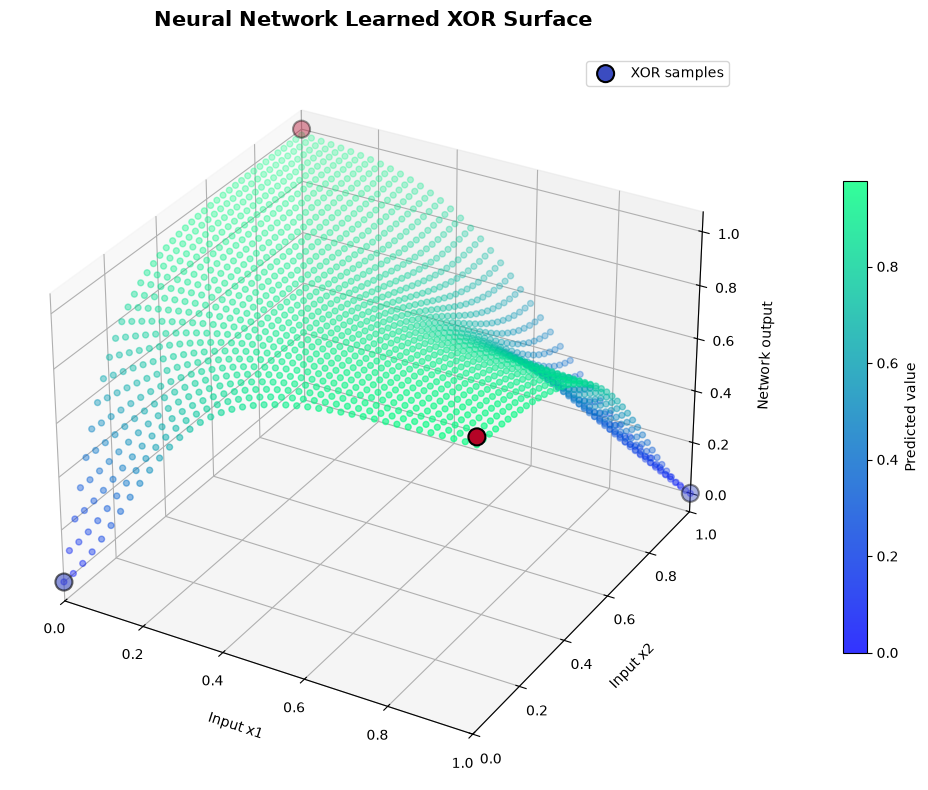

In [29]:
# ============================================================
# Plot 1 — Training Loss
# ============================================================


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    np.arange(1, len(loss_history) + 1),
    loss_history,
    color="royalblue",
    linewidth=2,
)

ax.set_title(
    "XOR Neural Network — Training Loss",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# Create Points for the Learned XOR Surface
# ============================================================

# Create a two-dimensional grid between 0 and 1.
#
# Increasing grid_resolution produces a smoother visualization but requires
# more forward passes through the network.


grid_resolution = 40

x1_values = np.linspace(0, 1, grid_resolution)
x2_values = np.linspace(0, 1, grid_resolution)

surface_points = []

for x1 in x1_values:
    for x2 in x2_values:
        model_input = np.array(
            [
                [x1],
                [x2],
            ]
        )

        prediction = predict(network, model_input)
        predicted_value = float(prediction[0, 0])

        surface_points.append(
            [
                x1,
                x2,
                predicted_value,
            ]
        )

surface_points = np.array(surface_points)


# ============================================================
# Plot 2 — 3D Learned XOR Surface
# ============================================================


fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

surface_plot = ax.scatter(
    surface_points[:, 0],
    surface_points[:, 1],
    surface_points[:, 2],
    c=surface_points[:, 2],
    cmap="winter",
    s=18,
    alpha=0.8,
)

# Add the four original XOR data points on top of the learned surface.

original_x1 = X[:, 0, 0]
original_x2 = X[:, 1, 0]
original_y = Y[:, 0, 0]

ax.scatter(
    original_x1,
    original_x2,
    original_y,
    c=original_y,
    cmap="coolwarm",
    edgecolors="black",
    linewidths=1.5,
    s=150,
    marker="o",
    label="XOR samples",
)

ax.set_title(
    "Neural Network Learned XOR Surface",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.set_xlabel("Input x1", labelpad=10)
ax.set_ylabel("Input x2", labelpad=10)
ax.set_zlabel("Network output", labelpad=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.colorbar(
    surface_plot,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label="Predicted value",
)

ax.legend()
plt.tight_layout()
plt.show()